# 02 - Tiền xử lý dữ liệu (Data Preprocessing)

---

## Mục tiêu của notebook này

Trong notebook trước (01 - EDA), chúng ta đã khám phá và hiểu rõ dữ liệu Pima Indians Diabetes. Ở notebook này, chúng ta sẽ thực hiện các bước **tiền xử lý dữ liệu** để chuẩn bị cho việc huấn luyện mô hình.

### Các bước tiền xử lý sẽ thực hiện:

1. **Xử lý Missing Values** (giá trị 0 bất hợp lý) → Imputation bằng median
2. **Chuẩn hóa dữ liệu** (StandardScaler) → Đưa các features về cùng scale
3. **Cân bằng dữ liệu** (SMOTE) → Xử lý imbalanced classes
4. **Mô hình hóa pipeline** tiền xử lý → Tổng kết quy trình
5. **Lưu dữ liệu** đã xử lý ra CSV → Sử dụng cho notebook tiếp theo

### Tại sao tiền xử lý quan trọng?

- Dữ liệu thô thường chứa **noise**, **missing values**, và **outliers** → ảnh hưởng đến chất lượng mô hình
- Các features có **scale khác nhau** (VD: Insulin 0-846 vs DPF 0.08-2.42) → các thuật toán distance-based sẽ bị bias
- **Imbalanced data** (65% không bệnh vs 35% bệnh) → mô hình sẽ thiên về class đa số

---

## Import thư viện cần thiết

Chúng ta sẽ sử dụng các thư viện sau:
- **pandas, numpy**: Xử lý dữ liệu
- **matplotlib, seaborn**: Trực quan hóa
- **sklearn**: Chia dữ liệu, chuẩn hóa, imputation
- **imblearn**: SMOTE để cân bằng dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
import os

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

---

## Section 1: Load dữ liệu gốc

Đầu tiên, chúng ta load lại dữ liệu gốc từ file CSV. Đây là bộ dữ liệu **Pima Indians Diabetes** đã được phân tích trong notebook EDA trước đó.

### Nhắc lại về dữ liệu:
- **768 mẫu**, **8 features** + 1 target (Outcome)
- **Vấn đề chính**: 5 cột (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) có giá trị **0** — đây là **missing values ẩn** vì các chỉ số sinh lý này không thể bằng 0 ở người sống

In [2]:
# Load dữ liệu gốc
df = pd.read_csv('../data/raw/diabetes.csv')

print(f'Shape: {df.shape}')
print(f'Số mẫu: {df.shape[0]}, Số cột: {df.shape[1]}')
print('\n--- 5 dòng đầu tiên ---')
df.head()

Shape: (768, 9)
Số mẫu: 768, Số cột: 9

--- 5 dòng đầu tiên ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Nhắc lại vấn đề: đếm giá trị 0 ở 5 cột có missing values ẩn
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Số lượng giá trị 0 (missing values ẩn) ở các cột:')
print('=' * 45)
for col in zero_cols:
    count_zero = (df[col] == 0).sum()
    pct = count_zero / len(df) * 100
    print(f'  {col:20s}: {count_zero:4d} ({pct:.1f}%)')

print('=' * 45)
print(f'  Tổng giá trị 0:       {sum((df[col] == 0).sum() for col in zero_cols)}')
print('\nĐây là vấn đề cần xử lý ở bước Imputation!')

Số lượng giá trị 0 (missing values ẩn) ở các cột:
  Glucose             :    5 (0.7%)
  BloodPressure       :   35 (4.6%)
  SkinThickness       :  227 (29.6%)
  Insulin             :  374 (48.7%)
  BMI                 :   11 (1.4%)
  Tổng giá trị 0:       652

Đây là vấn đề cần xử lý ở bước Imputation!


---

## Section 2: Tách Features và Target

Trước khi bắt đầu tiền xử lý, chúng ta cần tách dữ liệu thành:

- **X (Features)**: 8 cột đặc trưng đầu vào — các chỉ số y tế của bệnh nhân
- **y (Target)**: Cột `Outcome` — kết quả chẩn đoán (0 = không bệnh, 1 = có bệnh tiểu đường)

### Tại sao tách trước?
- Để đảm bảo target không bị ảnh hưởng bởi các bước tiền xử lý (imputation, scaling)
- Target là biến phân loại (0/1), không cần chuẩn hóa

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTỷ lệ Outcome:\n{y.value_counts()}')

Features shape: (768, 8)
Target shape: (768,)

Tỷ lệ Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


---

## Section 3: Chia dữ liệu Train/Test

Chúng ta chia dữ liệu thành **2 tập**:

| Tập | Tỷ lệ | Mục đích |
|-----|--------|----------|
| **Train** | 80% | Huấn luyện mô hình |
| **Test** | 20% | Đánh giá mô hình (unseen data) |

### Các tham số quan trọng:

- **`test_size=0.2`**: 20% dữ liệu dành cho test
- **`stratify=y`**: Đảm bảo tỷ lệ Outcome (0/1) được giữ nguyên trong cả train và test. Điều này rất quan trọng với dữ liệu imbalanced!
- **`random_state=42`**: Đảm bảo kết quả reproducible (có thể tái tạo lại)

### Nguyên tắc vàng: 
**Luôn chia Train/Test TRƯỚC khi tiền xử lý!** Nếu impute hoặc scale trên toàn bộ dữ liệu trước khi chia, sẽ gây **data leakage** — test set bị "nhìn" thông tin từ train set.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'\nTỷ lệ Outcome trong train:\n{y_train.value_counts()}')
print(f'\nTỷ lệ Outcome trong test:\n{y_test.value_counts()}')

X_train shape: (614, 8)
X_test shape: (154, 8)

Tỷ lệ Outcome trong train:
Outcome
0    400
1    214
Name: count, dtype: int64

Tỷ lệ Outcome trong test:
Outcome
0    100
1     54
Name: count, dtype: int64


---

## Section 4: Bước 1 - Xử lý Missing Values (Imputation)

### Vấn đề

Từ EDA, chúng ta đã biết rằng 5 cột sau có **giá trị 0 bất hợp lý** (missing values ẩn):

| Cột | Ý nghĩa | Giá trị 0 có hợp lý? |
|-----|---------|----------------------|
| `Glucose` | Nồng độ glucose | Không (người sống phải > 0) |
| `BloodPressure` | Huyết áp tâm trương | Không (huyết áp = 0 → tử vong) |
| `SkinThickness` | Độ dày nếp gấp da | Không (da luôn có độ dày > 0) |
| `Insulin` | Insulin huyết thanh | Không (cơ thể luôn sản xuất insulin) |
| `BMI` | Chỉ số khối cơ thể | Không (BMI = 0 → không có cơ thể) |

### Chiến lược xử lý

1. **Thay 0 → NaN**: Đánh dấu các giá trị 0 là missing
2. **Dùng `SimpleImputer` với `strategy='median'`**: Thay NaN bằng giá trị trung vị

### Tại sao chọn Median thay vì Mean?

- **Median robust hơn với outliers**: Nếu dữ liệu có outliers (VD: Insulin có max = 846), mean sẽ bị kéo lệch
- **Giữ nguyên phân bố tốt hơn**: Median không bị ảnh hưởng bởi các giá trị cực đoan
- **Ví dụ**: Nếu Insulin = [10, 20, 30, 40, **846**] → Mean = 189.2 (bị kéo lệch), Median = 30 (hợp lý hơn)

### Quan trọng: `fit` trên train, `transform` trên test

- `imputer.fit_transform(X_train)`: Học median từ train → áp dụng lên train
- `imputer.transform(X_test)`: Dùng median đã học từ train → áp dụng lên test
- **Tuyệt đối KHÔNG fit trên test** → tránh data leakage!

In [6]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Tạo copy để không ảnh hưởng dữ liệu gốc
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Thay 0 → NaN
for col in cols_to_impute:
    X_train_processed[col] = X_train_processed[col].replace(0, np.nan)
    X_test_processed[col] = X_test_processed[col].replace(0, np.nan)

print('Số lượng NaN sau khi thay thế (Train):')
print(X_train_processed.isnull().sum())

Số lượng NaN sau khi thay thế (Train):
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [7]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=X_test.columns,
    index=X_test.index
)

print('Giá trị median dùng để impute:')
for i, col in enumerate(X_train.columns):
    if col in cols_to_impute:
        print(f'  {col}: {imputer.statistics_[i]:.2f}')

print(f'\nSố NaN còn lại (Train): {X_train_imputed.isnull().sum().sum()}')
print(f'Số NaN còn lại (Test): {X_test_imputed.isnull().sum().sum()}')

Giá trị median dùng để impute:
  Glucose: 117.00
  BloodPressure: 72.00
  SkinThickness: 29.00
  Insulin: 125.00
  BMI: 32.40

Số NaN còn lại (Train): 0
Số NaN còn lại (Test): 0


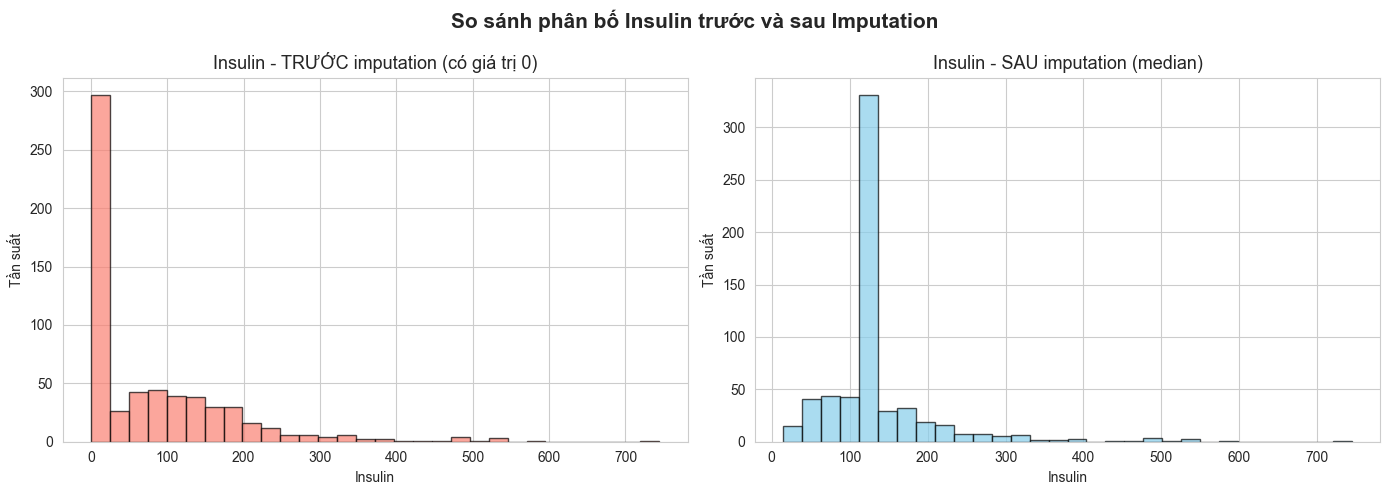

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train['Insulin'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Insulin - TRƯỚC imputation (có giá trị 0)', fontsize=13)
axes[0].set_xlabel('Insulin')
axes[0].set_ylabel('Tần suất')

axes[1].hist(X_train_imputed['Insulin'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Insulin - SAU imputation (median)', fontsize=13)
axes[1].set_xlabel('Insulin')
axes[1].set_ylabel('Tần suất')

plt.suptitle('So sánh phân bố Insulin trước và sau Imputation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Nhận xét kết quả Imputation

- **Trước imputation**: Cột `Insulin` có một spike lớn ở giá trị 0 (do missing values). Điều này làm phân bố bị lệch nghiêm trọng.
- **Sau imputation**: Spike ở giá trị 0 đã biến mất. Các giá trị 0 đã được thay bằng **median** của cột, giúp phân bố trở nên tự nhiên hơn.
- Tương tự cho các cột `Glucose`, `BloodPressure`, `SkinThickness`, `BMI`.

**Lưu ý**: Imputation bằng median là phương pháp đơn giản nhưng hiệu quả. Các phương pháp nâng cao hơn bao gồm: KNN Imputer, Iterative Imputer (MICE), hoặc dùng mô hình ML để predict missing values.

---

## Section 5: Bước 2 - Chuẩn hóa dữ liệu (Standardization)

### Tại sao cần chuẩn hóa?

Các features trong dữ liệu có **scale (phạm vi giá trị) rất khác nhau**:

| Feature | Min | Max | Range |
|---------|-----|-----|-------|
| Insulin | ~0 | ~846 | ~846 |
| Glucose | ~0 | ~199 | ~199 |
| BMI | ~0 | ~67 | ~67 |
| DiabetesPedigreeFunction | ~0.08 | ~2.42 | ~2.34 |

→ Nếu không chuẩn hóa, các features có range lớn (Insulin) sẽ **chiếm ưu thế** so với features có range nhỏ (DPF) trong các thuật toán distance-based.

### StandardScaler hoạt động như thế nào?

Công thức: **z = (x - μ) / σ**

Trong đó:
- **x**: giá trị gốc
- **μ (mu)**: mean (giá trị trung bình) của feature
- **σ (sigma)**: standard deviation (độ lệch chuẩn) của feature
- **z**: giá trị đã chuẩn hóa → mean = 0, std = 1

### Ảnh hưởng đến các thuật toán:

| Thuật toán | Cần chuẩn hóa? | Lý do |
|------------|----------------|-------|
| Logistic Regression | Rất cần | Distance-based, gradient descent |
| SVM | Rất cần | Distance-based |
| KNN | Rất cần | Distance-based |
| Decision Tree | Không cần | Rule-based, không phụ thuộc scale |
| Random Forest | Không cần | Ensemble of trees |
| XGBoost | Không cần | Tree-based |

→ Tuy nhiên, chuẩn hóa **không gây hại** cho tree-based models, nên chúng ta chuẩn hóa cho tất cả.

In [9]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test.columns,
    index=X_test.index
)

print('Thống kê sau chuẩn hóa (Train):')
print(X_train_scaled.describe().T[['mean', 'std', 'min', 'max']])

Thống kê sau chuẩn hóa (Train):
                                  mean       std       min       max
Pregnancies              -6.943414e-17  1.000815 -1.153338  3.980368
Glucose                  -1.099374e-16  1.000815 -2.190541  2.579408
BloodPressure             3.095606e-16  1.000815 -3.924957  4.065181
SkinThickness            -3.471707e-17  1.000815 -2.480958  7.874025
Insulin                  -4.339634e-18  1.000815 -1.559139  7.703814
BMI                       1.649061e-16  1.000815 -2.089621  5.081979
DiabetesPedigreeFunction -1.099374e-16  1.000815 -1.192094  5.610293
Age                      -1.084908e-16  1.000815 -1.045895  4.028617


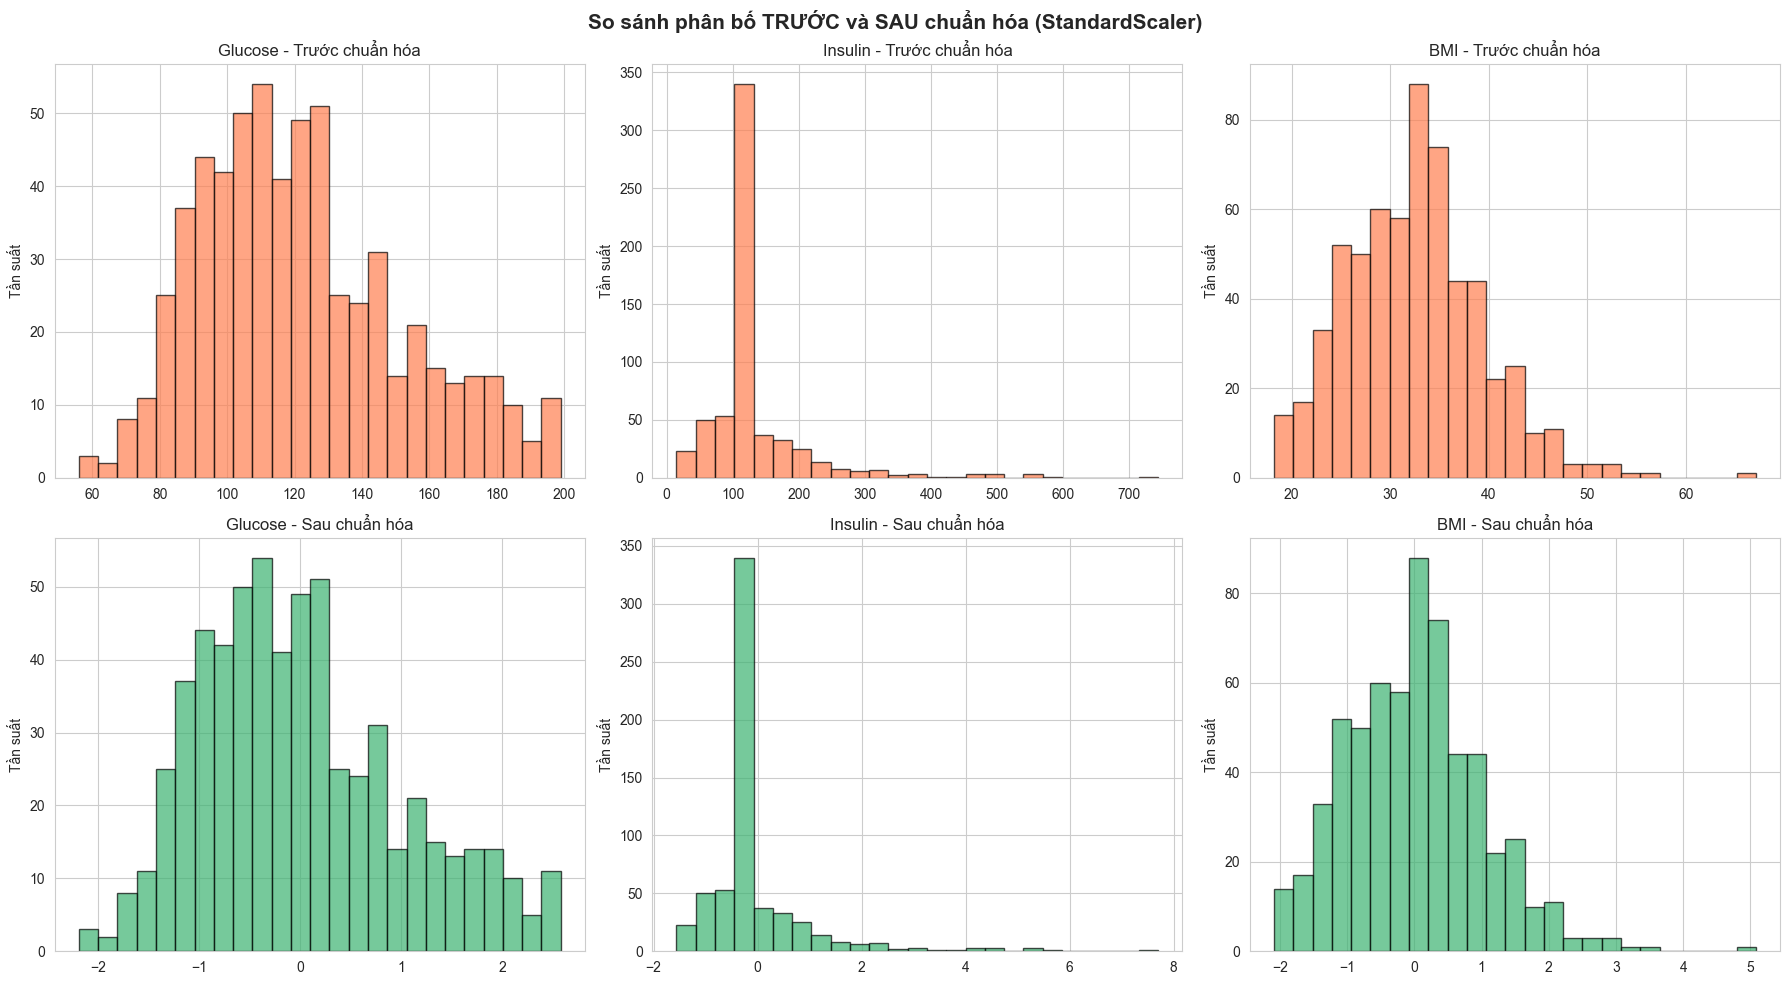

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_show = ['Glucose', 'Insulin', 'BMI']

for i, col in enumerate(features_to_show):
    axes[0, i].hist(X_train_imputed[col], bins=25, color='coral', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} - Trước chuẩn hóa', fontsize=12)
    axes[0, i].set_ylabel('Tần suất')
    
    axes[1, i].hist(X_train_scaled[col], bins=25, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col} - Sau chuẩn hóa', fontsize=12)
    axes[1, i].set_ylabel('Tần suất')

plt.suptitle('So sánh phân bố TRƯỚC và SAU chuẩn hóa (StandardScaler)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 6: Bước 3 - Cân bằng dữ liệu (SMOTE)

### Vấn đề: Imbalanced Data

Từ EDA, chúng ta đã biết dữ liệu **không cân bằng**:
- **Outcome = 0** (không bệnh): ~65%
- **Outcome = 1** (có bệnh): ~35%

→ Tỷ lệ xấp xỉ **2:1**. Mô hình sẽ có xu hướng predict class đa số (0) để đạt accuracy cao, nhưng **bỏ sót** nhiều ca bệnh thật.

### SMOTE là gì?

**SMOTE** = **S**ynthetic **M**inority **O**ver-sampling **TE**chnique

SMOTE tạo ra các **synthetic samples** (mẫu tổng hợp) cho lớp thiểu số bằng cách:

1. Chọn một mẫu thuộc lớp thiểu số
2. Tìm k nearest neighbors của nó (mặc định k=5)
3. Chọn ngẫu nhiên một neighbor
4. Tạo mẫu mới = mẫu gốc + random × (neighbor - mẫu gốc)

→ Kết quả: Lớp thiểu số được tăng lên bằng lớp đa số.

### Tại sao chọn SMOTE thay vì các phương pháp khác?

| Phương pháp | Ưu điểm | Nhược điểm |
|-------------|---------|------------|
| Random Oversampling | Đơn giản | Duplicate → overfitting |
| Random Undersampling | Đơn giản | Mất dữ liệu |
| **SMOTE** | **Tạo dữ liệu mới, đa dạng** | **Có thể tạo noise** |
| Class weights | Không thay đổi data | Phụ thuộc thuật toán |

### Quy tắc cực kỳ quan trọng:

**SMOTE chỉ được áp dụng trên TRAINING SET, TUYỆT ĐỐI KHÔNG áp dụng trên TEST SET!**

- Test set phải giữ nguyên phân bố thực tế để đánh giá chính xác
- Nếu SMOTE trên test → kết quả đánh giá sẽ bị sai lệch

In [11]:
print('TRƯỚC SMOTE:')
print(f'  Outcome=0: {(y_train == 0).sum()}')
print(f'  Outcome=1: {(y_train == 1).sum()}')
print(f'  Tỷ lệ: {(y_train == 0).sum()/(y_train == 1).sum():.2f}:1')

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'\nSAU SMOTE:')
print(f'  Outcome=0: {(y_train_balanced == 0).sum()}')
print(f'  Outcome=1: {(y_train_balanced == 1).sum()}')
print(f'  Tỷ lệ: {(y_train_balanced == 0).sum()/(y_train_balanced == 1).sum():.2f}:1')
print(f'\nShape train trước SMOTE: {X_train_scaled.shape}')
print(f'Shape train sau SMOTE: {X_train_balanced.shape}')

TRƯỚC SMOTE:
  Outcome=0: 400
  Outcome=1: 214
  Tỷ lệ: 1.87:1

SAU SMOTE:
  Outcome=0: 400
  Outcome=1: 400
  Tỷ lệ: 1.00:1

Shape train trước SMOTE: (614, 8)
Shape train sau SMOTE: (800, 8)


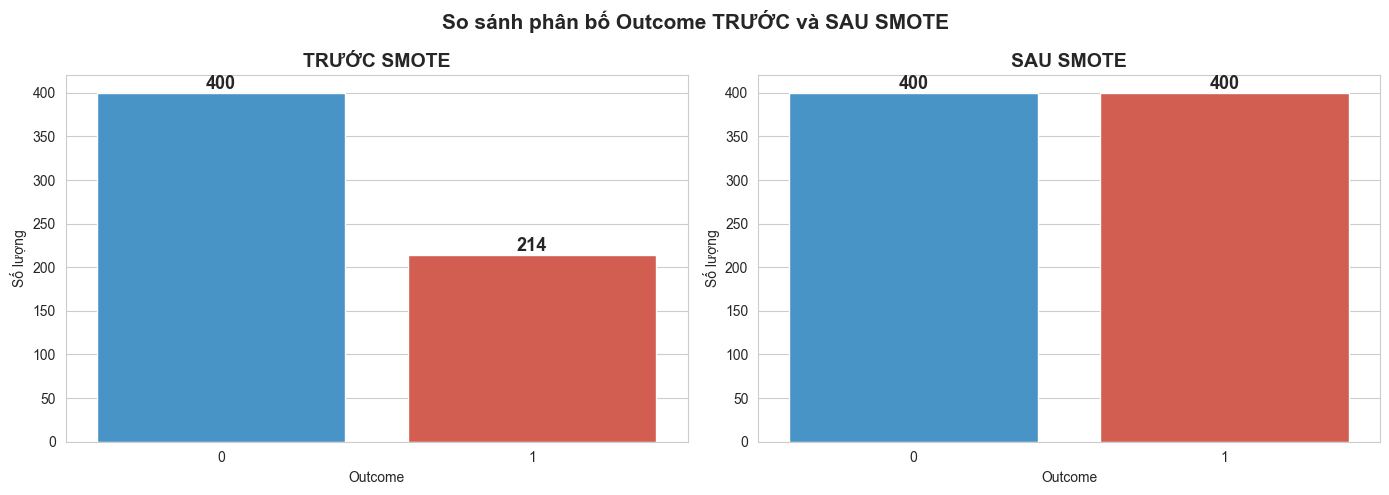

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('TRƯỚC SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Số lượng')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

sns.countplot(x=y_train_balanced, ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('SAU SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Số lượng')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.suptitle('So sánh phân bố Outcome TRƯỚC và SAU SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 7: Tổng kết Pipeline tiền xử lý

### Sơ đồ Pipeline hoàn chỉnh:

```
┌─────────────────────────────────────────────────────────────────┐
│                    PIPELINE TIỀN XỬ LÝ                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. DỮ LIỆU GỐC (768 mẫu, 8 features)                           │
│       │                                                         │
│       ▼                                                         │
│  2. TÁCH TRAIN/TEST (80/20, stratify)                           │
│       │                                                         │
│       ├── Train (614 mẫu) ──┐    ├── Test (154 mẫu) ──┐         │
│       │                     │    │                    │         │
│       ▼                     │    ▼                    │         │
│  3. IMPUTATION              │   IMPUTATION            │         │
│       (0 → NaN → median)    │    (transform only)     │         │
│       │                     │    │                    │         │
│       ▼                     │    ▼                    │         │
│  4. CHUẨN HÓA               │   CHUẨN HÓA             │         │
│       (StandardScaler fit)  │    (transform only)     │         │
│       │                     │    │                    │         │
│       ▼                     │    ▼                    │         │
│  5. SMOTE                   │   KHÔNG SMOTE           │         │
│       (cân bằng classes)    │    (giữ nguyên)         │         │
│       │                     │    │                    │         │
│       ▼                     │    ▼                    │         │
│  TRAIN SET FINAL            │    TEST SET FINAL       │         │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### Điểm mấu chốt cần nhớ:

1. **Tách Train/Test trước tiên** → tránh data leakage
2. **fit trên train, transform trên test** → đảm bảo test là "unseen data"
3. **SMOTE chỉ trên train** → test giữ nguyên phân bố thực tế

In [13]:
print('=== TỔNG KẾT PIPELINE TIỀN XỬ LÝ ===')
print(f'\n1. Dữ liệu gốc: {df.shape}')
print(f'2. Sau tách Train/Test:')
print(f'   - Train: {X_train.shape}')
print(f'   - Test:  {X_test.shape}')
print(f'3. Sau Imputation (shape không đổi):')
print(f'   - Train: {X_train_imputed.shape}')
print(f'   - Test:  {X_test_imputed.shape}')
print(f'4. Sau Chuẩn hóa (shape không đổi):')
print(f'   - Train: {X_train_scaled.shape}')
print(f'   - Test:  {X_test_scaled.shape}')
print(f'5. Sau SMOTE (chỉ train tăng):')
print(f'   - Train: {X_train_balanced.shape}')
print(f'   - Test:  {X_test_scaled.shape} (KHÔNG thay đổi!)')

=== TỔNG KẾT PIPELINE TIỀN XỬ LÝ ===

1. Dữ liệu gốc: (768, 9)
2. Sau tách Train/Test:
   - Train: (614, 8)
   - Test:  (154, 8)
3. Sau Imputation (shape không đổi):
   - Train: (614, 8)
   - Test:  (154, 8)
4. Sau Chuẩn hóa (shape không đổi):
   - Train: (614, 8)
   - Test:  (154, 8)
5. Sau SMOTE (chỉ train tăng):
   - Train: (800, 8)
   - Test:  (154, 8) (KHÔNG thay đổi!)


---

## Section 8: Lưu dữ liệu đã xử lý

Chúng ta lưu dữ liệu đã tiền xử lý ra file CSV để sử dụng ở các notebook tiếp theo:

| File | Nội dung | Mục đích |
|------|---------|----------|
| `train_preprocessed.csv` | Train set sau scale (trước SMOTE) | So sánh model có/không SMOTE |
| `test_preprocessed.csv` | Test set sau scale | Đánh giá model |
| `train_balanced_smote.csv` | Train set sau SMOTE | Train model với balanced data |

In [14]:
os.makedirs('../processed', exist_ok=True)

# Lưu dữ liệu đã tiền xử lý (sau scale, trước SMOTE)
train_processed = X_train_scaled.copy()
train_processed['Outcome'] = y_train.values
train_processed.to_csv('../processed/train_preprocessed.csv', index=False)

test_processed = X_test_scaled.copy()
test_processed['Outcome'] = y_test.values
test_processed.to_csv('../processed/test_preprocessed.csv', index=False)

# Lưu dữ liệu sau SMOTE
if isinstance(X_train_balanced, np.ndarray):
    train_balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns)
else:
    train_balanced_df = X_train_balanced.copy()
train_balanced_df['Outcome'] = y_train_balanced.values if hasattr(y_train_balanced, 'values') else y_train_balanced
train_balanced_df.to_csv('../processed/train_balanced_smote.csv', index=False)

print('Đã lưu dữ liệu thành công!')
print(f'  - ../processed/train_preprocessed.csv ({train_processed.shape})')
print(f'  - ../processed/test_preprocessed.csv ({test_processed.shape})')
print(f'  - ../processed/train_balanced_smote.csv ({train_balanced_df.shape})')

Đã lưu dữ liệu thành công!
  - ../processed/train_preprocessed.csv ((614, 9))
  - ../processed/test_preprocessed.csv ((154, 9))
  - ../processed/train_balanced_smote.csv ((800, 9))


---

## Kết luận

### Các bước tiền xử lý đã thực hiện:

1. **Xử lý Missing Values**: Thay giá trị 0 bất hợp lý → NaN → Impute bằng **median** (robust với outliers)
2. **Chuẩn hóa dữ liệu**: **StandardScaler** (mean=0, std=1) — quan trọng cho Logistic Regression, SVM, KNN
3. **Cân bằng dữ liệu**: **SMOTE** trên training set — tạo synthetic samples cho lớp thiểu số
4. **Lưu dữ liệu** đã xử lý ra CSV — sẵn sàng cho bước huấn luyện mô hình

### Nguyên tắc quan trọng đã tuân thủ:

- **Không data leakage**: Tách Train/Test trước, fit trên train, transform trên test
- **SMOTE chỉ trên train**: Test set giữ nguyên phân bố thực tế
- **Pipeline nhất quán**: Mọi bước xử lý đều có thứ tự rõ ràng và reproducible

---

### Tiếp theo: Notebook 03 — Huấn luyện mô hình

Trong notebook tiếp theo, chúng ta sẽ:
- Train các models (Logistic Regression, Random Forest, XGBoost, ...)
- So sánh kết quả **trước và sau** tiền xử lý
- Đánh giá bằng các metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC

---